In [61]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# 1. Data Preparation

This section loads the Titanic dataset and checks its structure before applying preprocessing techniques required for machine learning.

In [62]:
# Load the Titanic dataset
df = pd.read_csv("titanic.csv")
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [64]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [65]:
# Check missing values
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [66]:
missing_percentage = (df.isnull().mean() * 100).round(2)
print(missing_percentage[missing_percentage > 0])

age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64


# 2. Feature Selection

This section separates the target variable from the input features and removes columns that may cause data leakage.

In [67]:
# Separate the target variable
y = df["survived"]
# Remove the target and data leakage column
X = df.drop(columns=["survived", "alive"])
print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

X.head()

Feature Matrix Shape: (891, 13)
Target Variable Shape: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


# 3. Train-Test Split

This section splits the dataset into training and testing sets for model development and evaluation.

In [68]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42, stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (712, 13)
Testing Features : (179, 13)
Training Labels  : (712,)
Testing Labels   : (179,)


## Why Stratified Sampling?

The target variable (`survived`) is not perfectly balanced. Stratified sampling ensures that the same proportion of survived and not-survived passengers is maintained in both the training and testing datasets. This helps the model learn from a representative dataset and provides a more reliable evaluation.

# 4. Data Preprocessing Pipeline

This section creates a preprocessing pipeline to handle missing values, encode categorical features, and scale numerical features before training machine learning models.

In [69]:
# Separate numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical Features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


In [70]:
# Pipeline for numerical features
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
# Pipeline for categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [71]:
# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 5. Logistic Regression Model

This section trains a Logistic Regression model using the preprocessing pipeline and evaluates its performance on the test dataset.

In [72]:
# Create a machine learning pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])
# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [73]:
# Predict on the test set
y_pred = logistic_pipeline.predict(X_test)
# Predict probabilities
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [74]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.8268
Precision: 0.7879
Recall   : 0.7536
F1 Score : 0.7704
ROC AUC  : 0.8652


In [75]:
print("Classification Report\n")
print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



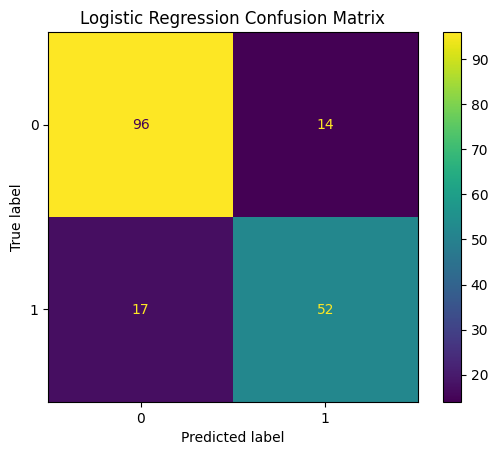

In [76]:
import os

# Create the directory if it doesn't exist
output_dir = "charts"
os.makedirs(output_dir, exist_ok=True)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.savefig(
    os.path.join(output_dir, "logistic_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

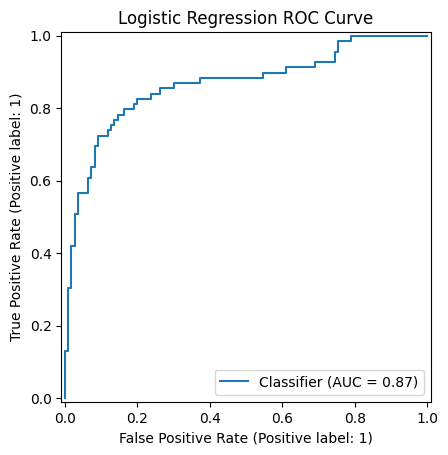

In [77]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Logistic Regression ROC Curve")
plt.savefig(
    "charts/logistic_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Decision Tree Classifier

This section trains a Decision Tree Classifier using the preprocessing pipeline and evaluates its performance on the test dataset.

In [78]:
# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
# Train the model
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [79]:
# Predict on the test dataset
y_pred_dt = decision_tree_pipeline.predict(X_test)
# Predict probabilities
y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [80]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")

Accuracy : 0.7933
Precision: 0.7353
Recall   : 0.7246
F1 Score : 0.7299
ROC AUC  : 0.7755


In [81]:
print("Classification Report\n")
print(classification_report(y_test, y_pred_dt))

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       110
           1       0.74      0.72      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



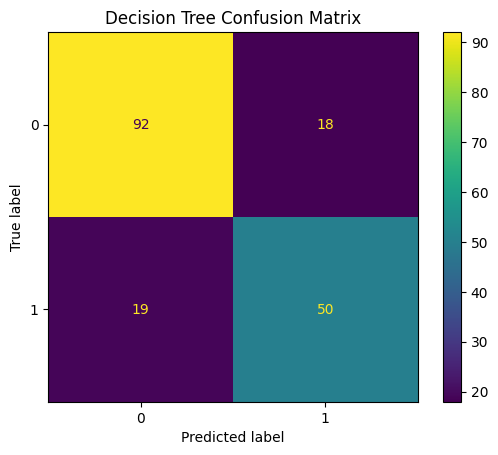

In [82]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.savefig(
    "charts/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

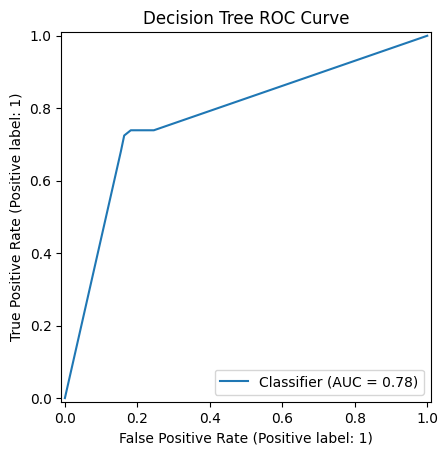

In [83]:
RocCurveDisplay.from_predictions(y_test, y_prob_dt)
plt.title("Decision Tree ROC Curve")
plt.savefig(
     "charts/decision_tree_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

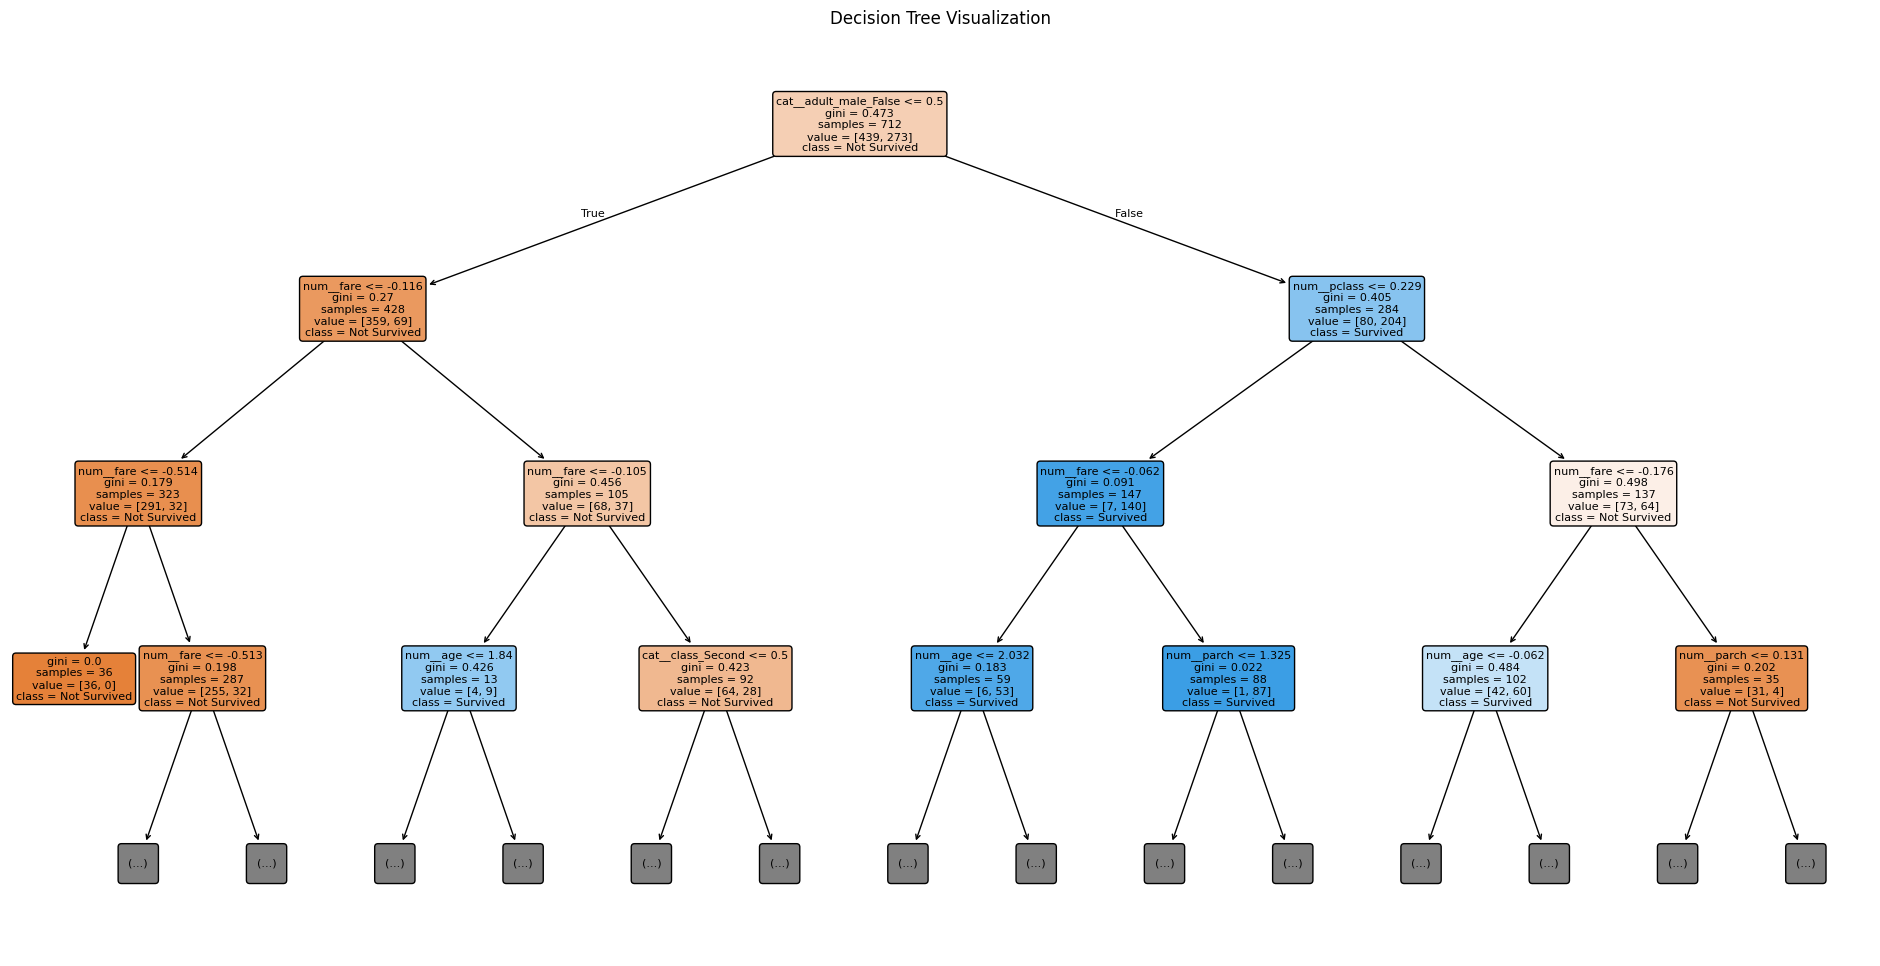

In [84]:
from sklearn.tree import plot_tree
# Visualize the first 3 levels of the trained Decision Tree
plt.figure(figsize=(24, 12))
plot_tree(
    decision_tree_pipeline.named_steps["classifier"],
    feature_names=decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.savefig(
    "charts/decision_tree_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Decision Tree Visualization Interpretation

The visualization shows the first three levels of the trained Decision Tree. Each node represents a decision based on one of the input features, while the leaf nodes represent the final prediction. The color intensity indicates the dominant class in each node. This visualization helps explain how the model makes classification decisions and improves the interpretability of the Decision Tree model.

## Decision Tree Interpretation

The Decision Tree model achieved an accuracy of **79.33%** on the test dataset.

- Accuracy: 79.33%
- Precision: 73.53%
- Recall: 72.46%
- F1 Score: 72.99%
- ROC-AUC Score: 77.55%

The Decision Tree model provides reasonable performance but performs slightly worse than the Logistic Regression model across all evaluation metrics. Based on the current results, Logistic Regression is the better-performing model.

# -----------------------------------------------------------
# 7. Random Forest Classifier

This section trains a Random Forest Classifier using the preprocessing pipeline and evaluates its performance on the test dataset.

In [85]:
# Create Random Forest pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ))
])
# Train the model
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [86]:
# Predict on the test dataset
y_pred_rf = random_forest_pipeline.predict(X_test)
# Predict probabilities
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [87]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

Accuracy : 0.8212
Precision: 0.8246
Recall   : 0.6812
F1 Score : 0.7460
ROC AUC  : 0.8301


In [88]:
print("Classification Report\n")
print(classification_report(y_test, y_pred_rf))

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



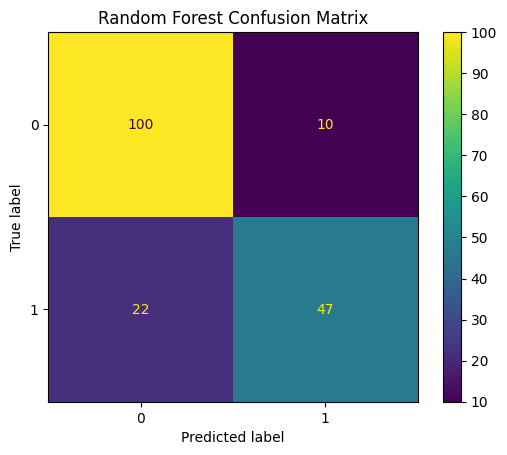

In [89]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.savefig(
    "charts/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

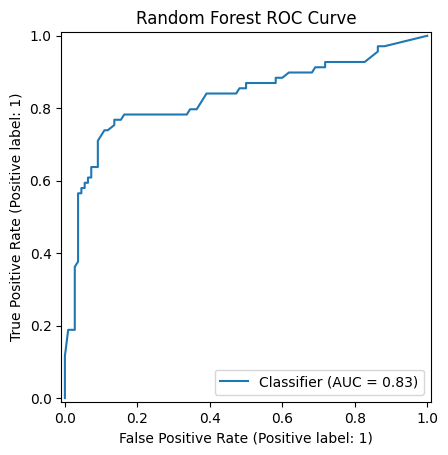

In [90]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest ROC Curve")
plt.savefig(
    "charts/random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Random Forest Interpretation

The Random Forest model achieved an accuracy of **82.12%** on the test dataset.

- Accuracy: 82.12%
- Precision: 82.46%
- Recall: 68.12%
- F1 Score: 74.60%
- ROC-AUC Score: 83.01%

The Random Forest model achieved the highest precision among the three classifiers, indicating that most passengers predicted as survivors were correctly classified. However, its recall was lower than Logistic Regression, meaning it missed more actual survivors. Overall, Logistic Regression provided a better balance between precision, recall, F1-score, and ROC-AUC, making it the preferred model for this project.

# ----------------------------------------
# 8. Model Comparison

The performance of all three machine learning models was compared using multiple evaluation metrics.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|---------:|----------:|--------:|---------:|---------:|
| Logistic Regression | 82.68% | 78.79% | 75.36% | 77.04% | 86.52% |
| Decision Tree | 79.33% | 73.53% | 72.46% | 72.99% | 77.55% |
| Random Forest | 82.12% | 82.46% | 68.12% | 74.60% | 83.01% |

## Conclusion

Among the three classification models, Logistic Regression achieved the best overall performance with an accuracy of **82.68%**, an F1-score of **77.04%**, and the highest ROC-AUC score of **86.52%**. Although Random Forest achieved the highest precision (**82.46%**), its recall was lower, indicating that it failed to identify more actual survivors. Therefore, Logistic Regression was selected as the final model because it provides the best balance between overall accuracy, recall, F1-score, and ROC-AUC.

# -------------------------------------------------------------
# 9. Handling Class Imbalance

This section compares three approaches for handling class imbalance:

1. Baseline Logistic Regression
2. Logistic Regression with `class_weight='balanced'`
3. Logistic Regression with SMOTE oversampling

The performance of all three approaches is compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [91]:
!pip -q install imbalanced-learn

In [92]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [93]:
# Create a Logistic Regression pipeline with balanced class weights
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train the model
balanced_pipeline.fit(X_train, y_train)
# Generate predictions
y_pred_bal = balanced_pipeline.predict(X_test)
y_prob_bal = balanced_pipeline.predict_proba(X_test)[:, 1]

# Evaluate model performance
print(f"Accuracy : {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bal):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_bal):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_bal):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_bal):.4f}")

Accuracy : 0.8268
Precision: 0.7714
Recall   : 0.7826
F1 Score : 0.7770
ROC AUC  : 0.8636


In [94]:
# Create a pipeline using SMOTE for oversampling the minority class
smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Train the model
smote_pipeline.fit(X_train, y_train)
# Generate predictions
y_pred_smote = smote_pipeline.predict(X_test)
y_prob_smote = smote_pipeline.predict_proba(X_test)[:, 1]

# Evaluate model performance
print(f"Accuracy : {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_smote):.4f}")

Accuracy : 0.8212
Precision: 0.7606
Recall   : 0.7826
F1 Score : 0.7714
ROC AUC  : 0.8577


In [95]:
# Compare the performance of all imbalance handling approaches
imbalance_results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight",
        "SMOTE"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_bal),
        accuracy_score(y_test, y_pred_smote)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_bal),
        precision_score(y_test, y_pred_smote)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_bal),
        recall_score(y_test, y_pred_smote)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_bal),
        f1_score(y_test, y_pred_smote)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_bal),
        roc_auc_score(y_test, y_prob_smote)
    ]
})

# Display the comparison table
imbalance_results.round(4)

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.8268,0.7879,0.7536,0.7704,0.8652
1,Class Weight,0.8268,0.7714,0.7826,0.7770,0.8636
2,SMOTE,0.8212,0.7606,0.7826,0.7714,0.8577


## Imbalance Handling Interpretation

Three methods were tested to handle class imbalance: Baseline, Class Weight, and SMOTE.

| Method       | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| ------------ | -------: | --------: | -----: | -------: | ------: |
| Baseline     |   82.68% |    78.79% | 75.36% |   77.04% |  86.52% |
| Class Weight |   82.68% |    77.14% | 78.26% |   77.70% |  86.36% |
| SMOTE        |   82.12% |    76.06% | 78.26% |   77.14% |  85.77% |

### Conclusion

The Baseline model gave the best overall performance. The Class Weight method improved the recall, but the precision became slightly lower. The SMOTE method also improved recall, but the accuracy and ROC-AUC were slightly lower. Based on these results, the Baseline Logistic Regression model was selected as the best model.

# ------------------------------------------------------------------
# 10. Hyperparameter Tuning

This section uses GridSearchCV to find the best parameters for the Random Forest model. The tuned model is then evaluated using the Out-of-Bag (OOB) score.

In [96]:
from sklearn.model_selection import GridSearchCV


In [97]:
# Create a Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42,oob_score=True ))
])
# Define the parameter grid
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

In [98]:
# Perform Grid Search
grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross Validation Score:
0.8217


In [99]:
# Get the best model
best_rf = grid_search.best_estimator_
# Predict on the test dataset
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")

Accuracy : 0.8212
Precision: 0.8627
Recall   : 0.6377
F1 Score : 0.7333
ROC AUC  : 0.8582


In [100]:
# Display the Out-of-Bag score
print(f"OOB Score: {best_rf.named_steps['classifier'].oob_score_:.4f}")

OOB Score: 0.8188


## Hyperparameter Tuning Interpretation

GridSearchCV was used to find the best parameters for the Random Forest model.

### Best Parameters

- Max Depth: 5
- Max Features: sqrt
- Number of Trees: 200

### Results

- Cross Validation Score: 82.17%
- Accuracy: 82.12%
- Precision: 86.27%
- Recall: 63.77%
- F1 Score: 73.33%
- ROC-AUC: 85.82%
- OOB Score: 81.88%

### Conclusion

The tuned Random Forest model achieved good accuracy and high precision. The OOB score (81.88%) also shows that the model performs well on unseen data. However, its recall was lower than the Logistic Regression model. Based on the overall results, Logistic Regression remained the best model for this project.

# ---------------------------------------------------------------
# 11. Regression Analysis

This section uses Linear Regression to predict the fare paid by passengers. The model is evaluated using MAE, RMSE, R² Score, and Adjusted R² Score.

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [102]:
# Create a copy of the dataset
regression_df = df.copy()
# Define the target variable
y_reg = regression_df["fare"]
# Remove the target and data leakage columns
X_reg = regression_df.drop(columns=["fare", "alive", "survived"])

In [103]:
# Split the dataset into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=42
)

In [104]:
# Identify numerical and categorical features
num_features_reg = X_reg.select_dtypes( include=["int64", "float64"]).columns.tolist()

cat_features_reg = X_reg.select_dtypes( include=["object", "bool", "category"]).columns.tolist()

In [105]:
# Create preprocessing pipelines
num_pipeline_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("num", num_pipeline_reg, num_features_reg),
    ("cat", cat_pipeline_reg, cat_features_reg)
])

In [106]:
# Create the Linear Regression pipeline
linear_pipeline = Pipeline([("preprocessor", preprocessor_reg), ("regressor", LinearRegression())])
# Train the model
linear_pipeline.fit(X_train_reg, y_train_reg)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [107]:
# Predict fare values
y_pred_reg = linear_pipeline.predict(X_test_reg)

In [108]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)
n = len(y_test_reg)
p = X_test_reg.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"MAE         : {mae:.4f}")
print(f"RMSE        : {rmse:.4f}")
print(f"R² Score    : {r2:.4f}")
print(f"Adjusted R² : {adjusted_r2:.4f}")

MAE         : 16.8948
RMSE        : 28.6345
R² Score    : 0.4701
Adjusted R² : 0.4318


## Regression Analysis Interpretation

The Linear Regression model was used to predict passenger fares.

### Results

- MAE: 16.89
- RMSE: 28.63
- R² Score: 0.4701
- Adjusted R² Score: 0.4318

### Conclusion

The model explained about **47%** of the variation in passenger fares. The prediction error was moderate, which means the model could predict fares reasonably well but still had room for improvement. Overall, the Linear Regression model gave acceptable performance for this dataset.

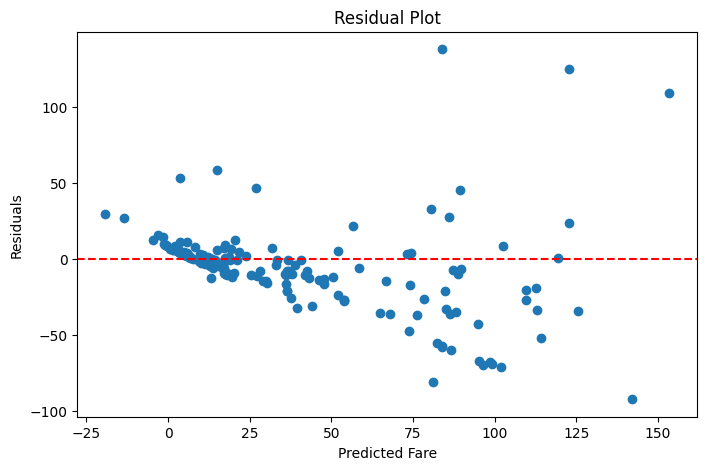

In [109]:
# Plot residuals
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8,5))
plt.scatter(y_pred_reg, residuals)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig(
    "charts/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Residual Plot Interpretation

The residuals are scattered around the zero line without a clear pattern. This shows that the model fits the data reasonably well. However, some points are far from the zero line, which means there are prediction errors for a few passengers.

# -----------------------------------------------------------
## 12 Final Recommendation

Three classification models were tested in this project: Logistic Regression, Decision Tree, and Random Forest.

Among them, Logistic Regression gave the best overall performance. It achieved the highest accuracy, F1 Score, and ROC-AUC score. It also provided a good balance between precision and recall.

Therefore, Logistic Regression was selected as the final model for predicting passenger survival.

# 13. Save the Best Model

This section saves the best performing model so that it can be used later without retraining.

In [110]:
import joblib
# Save the best model
joblib.dump(logistic_pipeline, "best_pipeline.joblib")

print("Best model saved successfully.")

Best model saved successfully.


# 14. Load the Saved Model

This section loads the saved model and uses it to make predictions on the test dataset.

In [111]:
# Load the saved model
loaded_pipeline = joblib.load("best_pipeline.joblib")
print("Model loaded successfully.")

Model loaded successfully.


In [112]:
# Make predictions using the loaded model
loaded_predictions = loaded_pipeline.predict(X_test)

print("First 10 Predictions:")
print(loaded_predictions[:10])

First 10 Predictions:
[0 0 0 0 1 1 1 0 0 0]


In [113]:
# Check whether the loaded model gives the same predictions
print("Predictions Match:", np.array_equal(y_pred, loaded_predictions))

Predictions Match: True


## Saved Model Interpretation

The trained Logistic Regression model was saved using Joblib and loaded successfully. The predictions from the loaded model matched the original model, showing that the model was saved and restored correctly.